In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw10.ipynb")

# Final Project: Predictive Modelling and Model Comparision

Names: Anand Ramabadran, Liam Oiknine

Student IDs: 518583 (Anand), 521644 (Liam)

Collaborators:

## Instructions

This homework is an _open-ended final project_ for our class.

We will focus on Data Profiling and Supervise Machine Learning including Feature Engineering, Feature Selection, and Model Selection & Comparison.

We will be using the techniques and approaches introduced throughout the course focusing on the following topics:

* [M0] Python for DS
* [M1] The DS and ML Workflows
* [M2] Exploratory Data Analsyis
* **[M3] Linear Regression (if applicable - depends on problem/dataset)**
* **[M4] Linear Classification (if applicable - depends on problem/dataset)**
* [M5] Sentiment Analysis (if applicable - depends on problem/dataset)
* [M6] Ethical Thinking for Data Science (if applicable - depends on problem/dataset)
* **[M7] Performance Evaluation: Overfitting & Cross-Validation**
* **[M8] Clustering K-Means (if applicable - depends on problem/dataset)** 
* **[M9] Similarity-based Learning K-NN (if applicable - depends on problem/dataset)**
* **[M10] More Models (Decision Tree, Random Forest, Neural Network) for Feature Engineering & Model Comparision & Selection**
* **[M11] DS Workflow in Python: Data Profiling and ML Pipelines**

The main focus of this project is majorly on the last modules [M7]-[M11]. In particular, it will be helpful to review **Lab 3 & hw 3 onwards for more clarification**.
Most of the things you will do in this final project are explained in `Lab10` and `Lab11`. Then, review the other labs and hws to recap the general workflow of our DS approaches to the various problems we have worked on so far. This will help you to be prepared for all the steps in this project, so that you do not miss anything. 

In general, you should feel free to import any package that we have previously used in class. Ensure that all plots have the necessary components that a plot should have (e.g. axes labels, a title, a legend).

> **!! Do not use any packages/methods/models that we did not discuss in this class !!**

Additionally, note that this assignment is more like a project than a typical homework and it will have a slightly different structure than the hws in the past. One of the reasons why Jupyter Notebooks are so popular in the field is because you can really treat them like notebooks to explain your findings as you discover them. In this assignment, we provide some **Problem** stubs following the DS workflow and you will need to fill in the analysis and structure as you go.

Furthermore, in addition to recording your collaborators on this homework, please also remember to cite/indicate all external sources used when finishing this assignment. This includes peers, TAs, and links to online sources. 

Frequently **save** your notebook!

### Collaborators and Sources
Furthermore, in addition to recording your **collaborators** on this homework, please also remember to **cite/indicate all external sources** used when finishing this assignment. 
> This includes peers, TAs, and links to online sources. 

Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process.

In [2]:
# collaborators and sources:
# Albert Einstein and Marie Curie
# https://developers.google.com/edu/python/strings

# your code here
answer = 'my answer'

### Submission instructions
* Submit this Python notebook, including your answers in the code cells as homework submission.
* **Feel free to add as many cells as you need to** — just make sure you don't change what we gave you. 
* **Does it spark joy?** Note that you will be partially graded on the presentation (_cleanliness, clarity, comments_) of your notebook so make sure you [Marie Kondo](https://lifehacker.com/marie-kondo-is-not-a-verb-1833373654) your notebook before submitting it.

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # run this first!

## 1. Introduction

For our final project this semester, we'll take a look at data for Melbourne Housing Price Prediction
https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot.


As you have seen throughout the semseter we have learned various techniques to solve a problem task (Classification, Regression, Clustering etc.) starting from problem formulation to EDA to model building to model evaluation and performing feaure engineering and selection in order to improve the model's performance.
You will be combining all the knowledge learned so far in this final project. You will be making assuptions and decisions on your own with appropriate justifications in writeups about how to improve the prediction model using all the tools and techniques learned so far and provide the best model at the end.


The project aims at building a model of housing prices to predict median house values in Melbourne using the provided dataset. This model should learn from the data and be able to predict the median housing price in any district, given all the other metrics.

Our goal will be to use this dataset to gain some insight about characteristics of different features.
We will be using data profiling from pandas and create models (hopefully more than 3) and compare them to find out which model performed the best and probably explain why it is the best model among all in this data.


### Problem 1.1

Download the data and load it in this notebook for further processing and analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
#load Data
path = "data/melb_data.csv"
#path = "data/melb_data.csv"
df = pd.read_csv(path)

In [2]:
#detailed summary of the full dataset including all features
print(df.info())

#Visualizing first few rows
print("\n")
df.head()

NameError: name 'df' is not defined

**Write-up!** Describe the data, answering questions including, but not limited to, these: Where does the data come from? How was it obtained? How many examples and features does the dataset have? What kinds of features are in the dataset? What values can these features take? What kind of data science problem is this? What application area does the dataset fall into? What kind of prediction (regression, classification or clustering) we are doing with this dataset and why?
> **Hint**: Recall, our goal is to build a model of housing prices to predict median house values.

### Dataset Description

#### 1. Source of the Data
- This dataset was compiled by someone named Tony Pico from publically available real estate sales that are posted weekly on a site called Domain.com.au. He cleaned the data and then supplied it to Kaggle [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) where it is made available to us. The data represents a snapshot of housing sales data from Melbourne, Australia at a time when the market was hot.

#### 2. How the Data Was Obtained
- The data likely comes from public real estate records and listings posted weekly on a site called Domain.com.au that seems to be specific to Australia and nearby areas. The dataset was compiled from this source, grouped together, organized, and cleaned by someone named Tony Pino before it was eventually made available for outside consumption on the web platform Kaggle.

#### 3. Dataset Dimensions
- **Number of Examples (Rows)**: 13,580
- **Number of Features (Columns)**: 21
- 
#### 4. Feature Breakdown and Descriptions

1. **`Suburb`**:
   - The name of the suburb where the property is located.
   - Categorical feature.

2. **`Address`**:
   - The full address of the property.
   - A text field that may not add predictive value directly but can provide location-specific details if processed further.

3. **`Rooms`**:
   - The number of rooms in the property.
   - Numerical feature.

4. **`Type`**:
   - The type of property:
     - 'h': House
     - 'u': Unit
     - 't': Townhouse
   - Categorical feature.

5. **`Price`**:
   - The selling price of the property (in Australian dollars).
   - Target variable (numerical).

6. **`Method`**:
   - The method of sale:
     - 'S': Sold
     - 'SP': Sold Prior to Auction
     - 'PI': Passed In (not sold at auction)
     - 'VB': Vendor Bid
     - 'SA': Sold After Auction
   - Categorical feature.

7. **`SellerG`**:
   - The name of the real estate agent or agency that sold the property.
   - Categorical feature.

8. **`Date`**:
   - The date the property was sold.
   - A date feature, which can be converted into numerical features like "year", "month", or "day of week."

9. **`Distance`**:
   - The distance of the property from Melbourne's Central Business District (CBD) in kilometers.
   - Numerical feature.

10. **`Postcode`**:
    - The postal code of the property's location.
    - Numerical, but more meaningful when treated as a categorical feature.

11. **`Bedroom2`**:
    - The number of bedrooms in the property.
    - Numerical feature (closely related to `Rooms`).

12. **`Bathroom`**:
    - The number of bathrooms in the property.
    - Numerical feature.

13. **`Car`**:
    - The number of car parking spaces available.
    - Numerical feature.

14. **`Landsize`**:
    - The land size of the property (in square meters).
    - Numerical feature (may contain outliers).

15. **`BuildingArea`**:
    - The building size of the property (in square meters).
    - Numerical feature (may contain missing values and outliers).

16. **`YearBuilt`**:
    - The year the property was built.
    - Numerical feature, often useful for age-related trends.

17. **`CouncilArea`**:
    - The council or administrative region where the property is located.
    - Categorical feature.

18. **`Lattitude`**:
    - The latitude coordinate of the property.
    - Numerical feature.

19. **`Longtitude`**:
    - The longitude coordinate of the property.
    - Numerical feature.

20. **`Regionname`**:
    - The general region where the property is located, e.g., "Southern Metropolitan."
    - Categorical feature.

21. **`Propertycount`**:
    - The number of properties in the suburb.
    - Numerical feature, indicating housing density or market size.

#### 5. Target Variable
- **`Price`**: The median house price (float), which we aim to predict.

#### 6. Value Ranges
- `Price`: Ranges from 85,000 to 9,000,000 AUD.
- `Rooms`: Ranges from 1 to 10.
- `Distance`: Ranges from 0.0 to 48.1 km from the CBD.
- `BuildingArea`: Ranges from 0 to 44,515 m² (likely contains outliers).
- `Landsize`: Ranges from 0 to 433,014 m² (also likely contains outliers).

#### 7. Type of Problem
- This is a **regression problem**. The target variable (`Price`) is continuous and numerical, and regression models are used to predict quantitative values. Trying to frame this as a classification problem would necessitate some loss of data, as we would have to group prices into set ranges that would have categorical names. We would be unable to capture the continuous values of prices that are very important in the context of this problem.

#### 8. Application Area
- The dataset applies primarily to the **real estate sector** for housing price analysis, predictions, and market trend studies. The dataset itself can be useful for predicting prices of new houses being put on the market, comparing predicted prices to actual sale prices, or even analyzing the housing market ass a whole to derive trends being followed. The dataset documentation notes that this data was recorded at a time when the Australian real estate market was hot. Taking this into account, this dataset could prove a valuable comparison tool for understanding real estate and broader economic trends in Australia over time.

#### 9. Prediction Type
- We are performing **regression prediction** to estimate the median house price using features such as location, type, size, and amenities as inputs. Again, we want to caputer the continouos values reflected in the pricing data, so that we can provide an estimate down to the exact dollar and cent, which is why we use a regression prediction.

### Problem 1.2: Getting Familiar with the Data

Generate the data report using __ProfileReport__ as we did in lab 11.

In [ ]:
import ydata_profiling
from ydata_profiling import ProfileReport

# Generate the Profile Report
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)

# Display the report in a Jupyter Notebook
profile.to_notebook_iframe()
profile.to_file("output_report.html")
plt.savefig("profile_report.png")
plt.show()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Problem 1.3: Data Description

**Write-up!** What are the major highlights and interesting aspects in the report generated in the previous cell (or in your own EDA process). 
Describe your insights using the data/features/visualizations/statistics. Be sure to consider the relationship among features such as correlation and interaction, as well as distributions, missing data, outliers. Include additional visualizations as necessary.

#### **Missing Data**
- Columns like `BuildingArea` and `YearBuilt` have a significant number missing values (47.5% and 39.6% respectively). If left unattended, this could limit the functions that can be run on the dataset, or disrupt the quality of the data downstream. We will need to consider ways to account for these large amounts of missing data such as imputation, deleting rows with missing values, or deleting columns/features with missing values.
#### **Outliers**: 
  - Features like `Landsize`, and `BuildingArea` show extreme values that fall well beyond the scope of the majority of the data. We included some additional visualization below to show just how far off the outliers are from the rest of the data. This will require attendence such as eliminating outliers by using an interquartile range, or scaling the data in some way to transfrom it to fit on a reasonable scale.
#### **Zeros**: 
  - The `Landsize` feature is 14.3% zeros. Likewise, the `Car` feature is 7.6% zeros. The zeros in these columns may represent missing or non-applicable values, and could potentially be disregarded or dropped for greater accuracy.
#### **Distribution Insights**:
  - `Price`: Highly skewed with a minimum of AUD 85,000 and a maximum of AUD 9,000,000.
  - `Landsize`, `BuildingArea`, `Distance`: Skewed distributions
  - Additional visualization are also included, see the original and log transformed plots shown below. Final decision as to whether to use log transformation can be made after examining performance metrics
##
***THIS NOTE INSERTED POST ALL THE ANALYSIS***
   - Log transformation applied on 'Price' yields meaningfullly better accuracy and lower RMSE. However, the RMSE value becomes challenging to interpret. So, the analysis was done with just the non-transformed 'Price' data for the purposes of this project. As for the features, using log transformation on BuildingArea and Landsize did not yield much improvement, but log transformation on Distance yielded modest benefit and was thus incorporated during the Feature Engineering phase.

#### **Feature Interactions and Correlations**
- **Heatmap Insights**:
  - `Rooms`, `Bedroom2`, and `Bathroom` are positively correlated with `Price`, reflecting intuitive relationships in housing features as we would expect greater values in these features to correlate to higher sale prices. `BuildingArea` and `LandSize` show a positive correlation in the Panda Profile heatmap, however the calculation from the standard corr() function shows a very low correlation. Likely this is due to the extreme skewness and/or missing values. A log transformation confirms this. See additional visualization for correlation of numerical variables with `Price`.
- **Categorical Variables**:
    - The Pandas Profile does not address the correlation of categorical variables with `Price`. Intuitively, `Price` should be correlated with `Type`, the type of the house. A correlation analysis of the encoded `Type`with `Price`confirms this intuition. Additional visualization is included below to reflect this as well.
- **Region Analysis**:
  - Features like `Regionname` and `CouncilArea` may act as proxies for location impact on pricing.

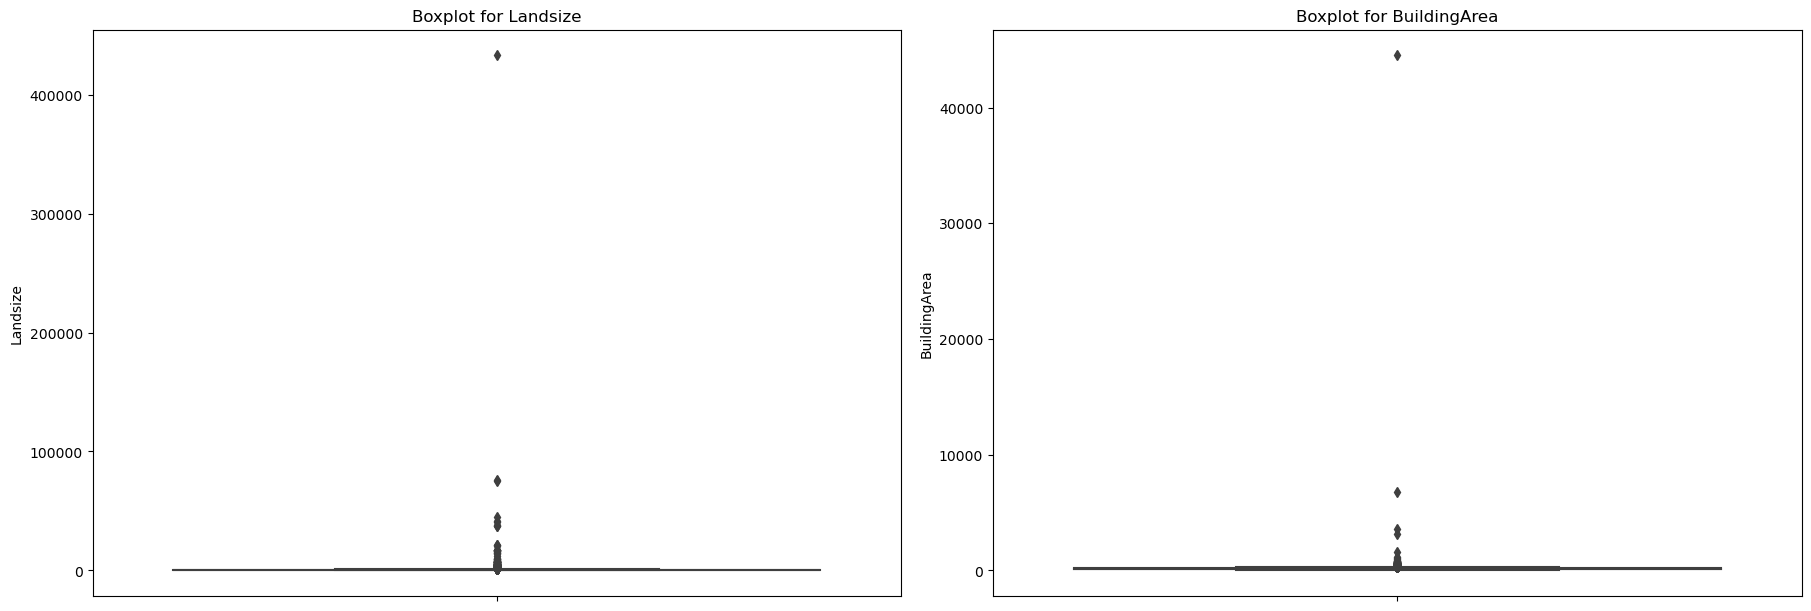

In [8]:
# Outlier features
outlier_features = ['Landsize', 'BuildingArea']

# Create subplots in a 1x3 layout
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# Generate boxplots
for i, feature in enumerate(outlier_features):
    sns.boxplot(data=df, y=feature, ax=axes[i])
    axes[i].set_title(f'Boxplot for {feature}')
    axes[i].set_ylabel(feature)

# Display the plots
plt.show()

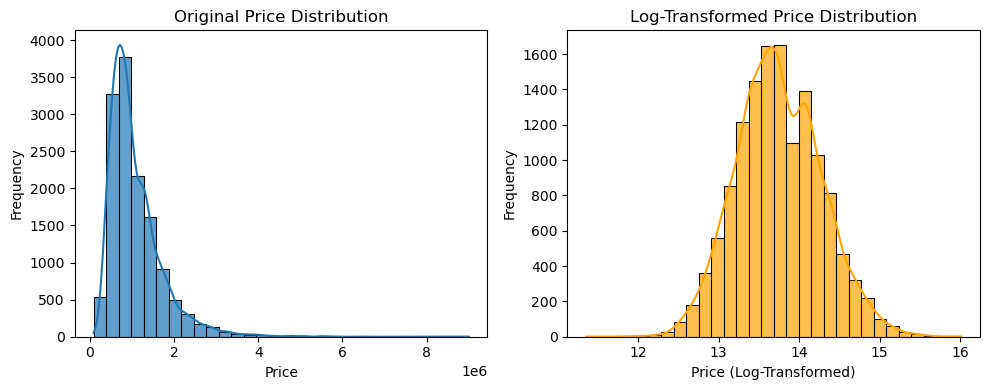

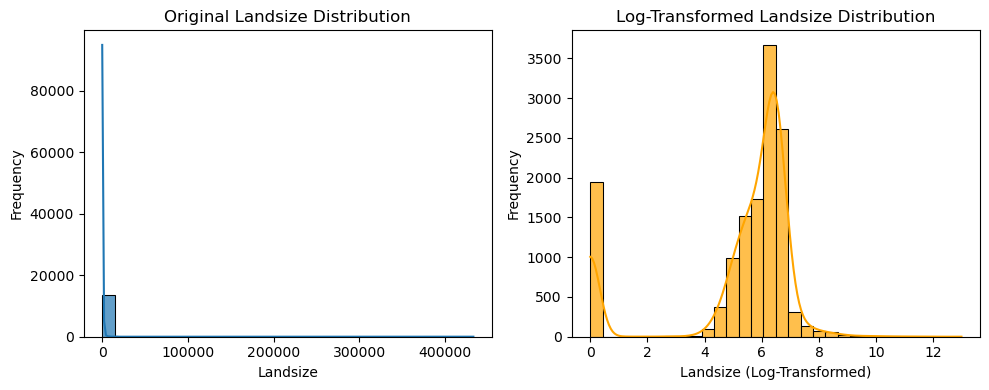

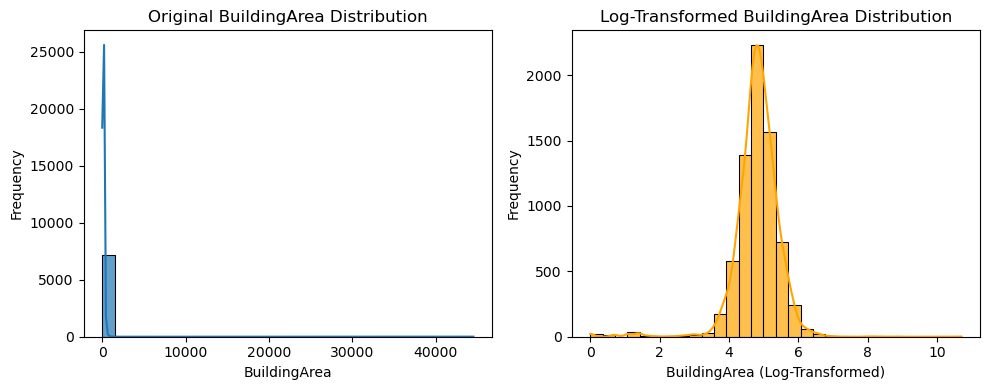

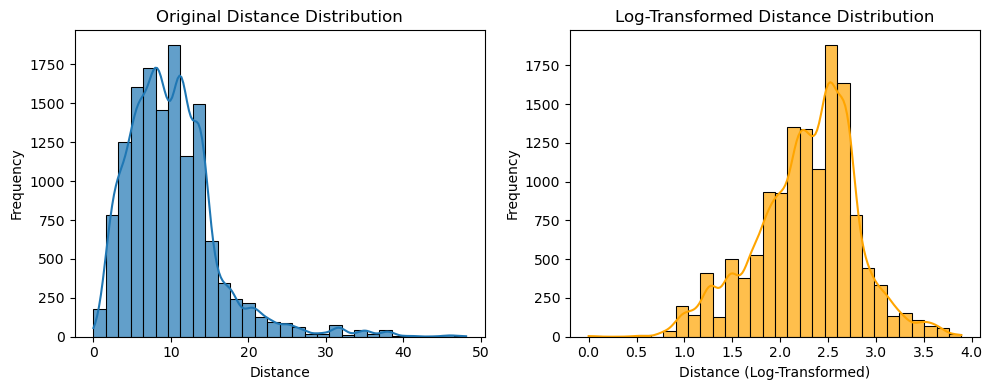

In [9]:
# Skewed features
skewed_features = ['Price', 'Landsize', 'BuildingArea', 'Distance']

# Generate comparison plots for each feature
for feature in skewed_features:
    # Apply log transformation only to non-zero, non-NaN values
    transformed = np.log1p(df[feature])
    
    # Plot original vs. log-transformed distributions
    plt.figure(figsize=(10, 4))

    # Original distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature].dropna(), kde=True, bins=30, alpha=0.7)
    plt.title(f'Original {feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Log-transformed distribution
    plt.subplot(1, 2, 2)
    sns.histplot(transformed.dropna(), kde=True, bins=30, alpha=0.7, color='orange')
    plt.title(f'Log-Transformed {feature} Distribution')
    plt.xlabel(f'{feature} (Log-Transformed)')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

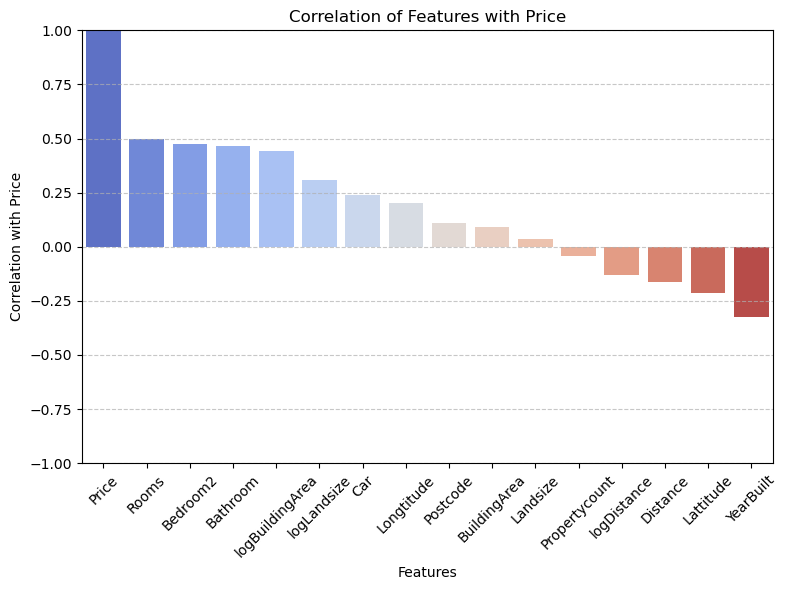

In [10]:
# Correlations of numerical variable

# Test log transform for skewed variables
df['logLandsize'] = np.log1p(df['Landsize'])
df['logBuildingArea'] = np.log1p(df['BuildingArea'])
df['logDistance'] = np.log1p(df['Distance'])

numeric_data = df.select_dtypes(include=[np.number])

# Recompute correlation with 'Price' for all numerical features
updated_price_correlations = numeric_data.corr()["Price"].sort_values(ascending=False)

# Visualizing the correlations with Price
plt.figure(figsize=(8, 6))
sns.barplot(x=updated_price_correlations.index, y=updated_price_correlations.values, palette="coolwarm")
plt.title("Correlation of Features with Price")
plt.xlabel("Features")
plt.ylabel("Correlation with Price")
plt.xticks(rotation=45)
plt.ylim(-1, 1)  # Ensuring the scale is from -1 to +1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Correlations of Type categories with Price:
Type_h    0.395035
Type_t   -0.066377
Type_u   -0.393378
Name: Price, dtype: float64


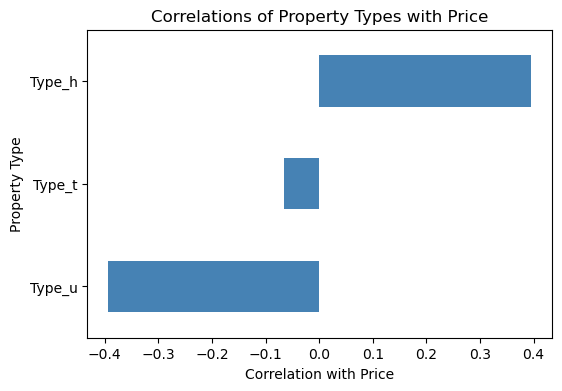

In [11]:
# Encode'Type'
type_encoded = pd.get_dummies(df['Type'], prefix='Type')
df_encoded = pd.concat([df, type_encoded], axis=1)

# Correlation Analysis with Price
correlations = df_encoded[['Price'] + list(type_encoded.columns)].corr()

# Display correlations of 'Type' categories with 'Price'
type_price_corr = correlations.loc['Price', type_encoded.columns]
print("Correlations of Type categories with Price:")
print(type_price_corr)

# Plotting Correlations
plt.figure(figsize=(6, 4))
type_price_corr.sort_values().plot(kind='barh', color='steelblue')
plt.title('Correlations of Property Types with Price')
plt.xlabel('Correlation with Price')
plt.ylabel('Property Type')
plt.show()

### Problem 1.4: Split the Data

Extract input (X) and output (y) data from the dataset. 

Use the train and test split from the scikit learn library to split the data into 80% training and 20% testing.

Then, initalize the Kfolds. Be sure to use these folds when executing cross validation below so that the results are comparable.

In [12]:
from sklearn.model_selection import train_test_split, KFold

# Extract input (X) and output (y) data
X = df.drop(columns=['Price'])  # Remove the target variable
y = df['Price']  # Target variable

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Verify the splits
kf_splits = [(train_idx, test_idx) for train_idx, test_idx in kf.split(X_train)]

# Display some information
print(f"Train Size: {X_train.shape[0]}")
print(f"Test Size: {X_test.shape[0]}")
print(f"Example Fold:")
print(f"  Fold 1 Train Indices: {kf_splits[0][0][:5]}")
print(f"  Fold 1 Test Indices: {kf_splits[0][1][:5]}")

Train Size: 10864
Test Size: 2716
Example Fold:
  Fold 1 Train Indices: [1 2 4 5 6]
  Fold 1 Test Indices: [ 0  3  8 10 14]


**Write-up!** Why 80% train and 20% test split is considered a good practice? How would you pick the train-test split size if the dataset is relatively small or large? What is the purpose of using cross validation technique and how does it ensure model robustness? What is Data snooping and how do you avoid it?

### Why is 80%-20% Train-Test Split Considered Good Practice?

The 80%-20% train-test split strikes a balance between having:
1. **Sufficient Training Data:**
   - The model needs enough data to learn patterns effectively. With 80%, the model can generalize better. If we used a smaller percentage of the total data for training, the model would have less to learn from and could consequentaly be less accurate at predicting the target.
   
2. **Meaningful Test Evaluation:**
   - While we want to reserve as much of the data as we can for testing, we must also set aside enough data for testing so that we can get an accurate measure of performance of the model. The 20% test set is large enough to provide reliable performance estimates, ensuring that the evaluation metrics are meaningful. Going above 20% detracts from training data, and going below 20% decreases the reliability of our insights on model performance.

This split is not universal but works well for many datasets, offering a balance between training the model and testing its generalizability.

---

### How to Pick Train-Test Split Size?

1. **For Small Datasets:**
   - Use more data for training (e.g., 90%-10% split). Any model benefits from more data to learn meaningful patterns. Small datasets require a sacrafice in testing data to ensure enough data in the training set for the model to learn to predict the target.
   - Alternatively, we can use **cross-validation** to maximize the use of available data without creating a separate test set.

2. **For Large Datasets:**
   - A smaller percentage (e.g., 70%-30% or 60%-40%) for the test set may be fine since even a small percentage of a large dataset provides a substantial amount of data for the test set.
   - Larger test sets help detect subtle model weaknesses that would cause error when deployed on actaul data.

3. **When in Doubt:**
   - Use cross-validation to evaluate the model on different training/testing splits, ensuring robust performance.

---

### Purpose of Cross-Validation and How It Ensures Model Robustness

**Purpose:**
Cross-validation (CV) evaluates a model's performance by splitting the training data into multiple subsets. The model is trained on one subset and validated on another. This process is repeated for all subsets, and the performance is averaged to provide a reliable estimate.

**Ensuring Robustness:**
1. **Reduces Variance:**
   - Performance is averaged over multiple splits, reducing reliance on a single train-test split.
   
2. **Uses Data Efficiently:**
   - All data points are used for both training and validation, ensuring the model learns from the entire dataset.

3. **Detects Overfitting:**
   - Consistent performance across folds indicates that the model generalizes well, while large discrepancies suggest overfitting.

**Example:**
In k-fold CV, the data is split into \( k \) folds. For each fold:
   - Train on \( k-1 \) folds.
   - Validate on the remaining fold.
   - Repeat \( k \) times and average the results.

---

### What is Data Snooping and How to Avoid It?

**Definition:**
Data snooping occurs when information from the test set (or validation set) is used during model training or preprocessing, leading to overly optimistic performance estimates and reduced generalizability.

**Examples of Data Snooping:**
1. Imputing missing values using statistics calculated from the entire dataset (including the test set).
2. Scaling data using the mean and standard deviation of the entire dataset.
3. Selecting features or hyperparameters based on the test set.

**How to Avoid Data Snooping:**
1. **Isolate Test Data:**
   - Perform all preprocessing (e.g., imputation, scaling) and model training **only on the training set**.

2. **Pipeline Usage:**
   - Use pipelines to ensure transformations are fitted on training data and applied to test data without leakage.

3. **Validation Set for Hyperparameter Tuning:**
   - Use a validation set (or cross-validation) for tuning, leaving the test set untouched until the final evaluation.

4. **Proper K-Fold CV Implementation:**
   - Apply preprocessing separately within each fold to prevent leakage between training and validation splits.

By strictly isolating the test data and using robust validation practices, data snooping can be avoided, ensuring fair and reliable model evaluation.

## Problem 2: Preprocessing and Baseline Models

### Problem 2.1: Preprocessing for the Baseline Models

Let's start by preprocessing the data so that we can train some baseline models. Note that categorical variables will need to be encoded and missing values should be appropriately delt with using imputation. Also, some models may require scaling. Imputation and scaling should be done in a manner that aovids data snooping.
> Hint: The use of Scikit-Learn's Pipelines are highly encouraged!

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

def preprocess_data(X_train, X_test, numerical_columns, categorical_columns):
    """
    Preprocesses the training and testing datasets.
    - Uses KNNImputer for missing numerical values.
    - Uses most_frequent strategy for missing categorical values.
    - Scales numerical columns with RobustScaler.
    - Encodes categorical columns.

    Parameters:
        X_train (pd.DataFrame): Training dataset.
        X_test (pd.DataFrame): Testing dataset.
        numerical_columns (list): List of numerical column names.
        categorical_columns (list): List of categorical column names.

    Returns:
        X_train_preprocessed (np.ndarray): Preprocessed training dataset.
        X_test_preprocessed (np.ndarray): Preprocessed testing dataset.
    """
    
    # Preprocessing pipeline for numerical data
    numerical_pipeline = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)), # Imputation with KNNImputer
        ('scaler', RobustScaler())              # Scaling with RobustScaler
    ])

    # Preprocessing pipeline for categorical data
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputation with most_frequent strategy
        ('encoder', OneHotEncoder(handle_unknown='ignore'))    # Encoding categorical features
    ])

    # Combine pipelines into a column transformer
    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_columns),
        ('cat', categorical_pipeline, categorical_columns)
    ])

    # Fit the preprocessor on the training data and transform both train and test
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)

    return X_train_preprocessed, X_test_preprocessed

# We ignored several irrelevant variables and used the most relevant ones based on the profiling analysis
# While feature selection later will remove non-correlated features anyway, 
# the initial runs, especially for Random Forest take too much time if all features are left in.
# This is because the number of categorical variables explode into too many features

numeric_cols = ['Rooms', 'Bedroom2', 'Bathroom', 'Distance', 'YearBuilt', 'Landsize', 'BuildingArea','Car', 'Lattitude', 'Longtitude']
categoric_cols = ['Suburb', 'Type', 'Method', 'SellerG', 'Postcode','CouncilArea','Regionname']

X_train_preprocessed, X_test_preprocessed = preprocess_data (X_train, X_test, numeric_cols, categoric_cols)

# Output the shapes of the transformed datasets
print(f"Transformed Training Data Shape: {X_train_preprocessed.shape}")
print(f"Transformed Testing Data Shape: {X_test_preprocessed.shape}")

Transformed Training Data Shape: (10864, 806)
Transformed Testing Data Shape: (2716, 806)


### Problem 2.2: Perform Linear Regression

Perform Linear Regression on training data. Predict the output for the test dataset using the fitted model. Print the root mean squared error (RMSE) and R^2 value from Linear Regression for test data set.


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_linear_model(X_train, X_test, y_train, y_test):
    """
    Evaluates a linear regression model and returns R-squared, Adjusted R-squared, and RMSE.

    Parameters:
        X_train: Training feature set
        X_test: Test feature set
        y_train: Training target variable
        y_test: Test target variable

    Returns:
        r2 (float): R-squared value
        adjusted_r2 (float): Adjusted R-squared value
        rmse (float): Root Mean Squared Error
    """
    # Step 1: Initialize the Linear Regression model
    linear_reg_model = LinearRegression()

    # Step 2: Fit the model on the training data
    linear_reg_model.fit(X_train, y_train)

    # Step 3: Predict the output for the test dataset
    y_pred = linear_reg_model.predict(X_test)

    # Step 4: Calculate RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Step 5: Calculate Adjusted R-squared
    n = X_test.shape[0]  # Number of observations
    p = X_test.shape[1]  # Number of predictors
    adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

    # Return the metrics
    return r2, adjusted_r2, rmse

r2, lin_adjusted_r2, lin_rmse = evaluate_linear_model (X_train_preprocessed, X_test_preprocessed, y_train, y_test)

# Print the results
print(f"Root Mean Squared Error (RMSE): {lin_rmse:.4f}")
print(f"R-squared (R^2): {r2:.4f}")
print(f"Adjusted R-squared (R^2): {lin_adjusted_r2:.4f}")

Root Mean Squared Error (RMSE): 343487.4431
R-squared (R^2): 0.7030
Adjusted R-squared (R^2): 0.5776


**Write-up!** What does R^2 tell us about the model's performance? What does RMSE tell us about the model's performance?

### Understanding the Evaluation Metrics

#### **R-squared (\( R^2 \)):**
- **Our Result:**
  - \( Adjusted R^2 = 0.5776)\: The model explains **57.8%** of the variance in house prices using the given features.
  - This indicates that the model is capturing some patterns but leaves a significant amount of variance unexplained. For a linear regression model, this might be a sign that:
    - The relationship between features and target is not entirely linear.
    - Some important features might be missing.
    - Perhaps some features have linear correlation with price, while others have non-linear relationships
    - Non-linear models may perform better.
---

#### **Root Mean Squared Error (RMSE):**
- **Our Result:**
  - \( RMSE = 343,487 \): On average, the model's predictions differ from actual house prices by approximately $343,497.
  - This value is high relative to typical house prices and suggests the model has substantial error in its predictions.
  - As data scientists in the real world considering the practical applications of the models we build, this could no be considered an adequate error level, and we must consider other alternatives to find more accurate models.
---

### Combining the Metrics:

- \( Adjusted R^2 = 0.5776 \): Suggests that the model explains some of the variability in house prices but has room for improvement.
- \( RMSE = 343,487 \): Indicates that the errors in the predictions are large, likely making the model's predictions impractical for precise applications like pricing homes.

### Problem 2.3 : Perform K-Nearest Neighbors Regression

Perform K-Nearest Neighbors Algorithm for Regression using cross validation to tune any hyperparameters, such as `n_neighbors`.

Then, using the optimal hyperparameters, train a K-Nearest Neighbors Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from K-Nearest Neighbors Regression on the test datset.

In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

def evaluate_knn_model(X_train, X_test, y_train, y_test, kf):
    """
    Evaluates a KNN regression model with hyperparameter tuning using GridSearchCV.
    
    Parameters:
        X_train: Training feature set
        X_test: Test feature set
        y_train: Training target variable
        y_test: Test target variable
        kf: KFold cross-validator
        
    Returns:
        best_params (dict): Best hyperparameters from GridSearchCV
        r2 (float): R-squared value
        adjusted_r2 (float): Adjusted R-squared value
        rmse (float): Root Mean Squared Error
    """
    # Step 1: Define the KNN regressor
    knn_model = KNeighborsRegressor()
    
    # Step 2: Define hyperparameter grid
    param_grid = {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # Manhattan and Euclidean distances
    }
    
    # Step 3: Perform GridSearchCV
    grid_search = GridSearchCV(
        estimator=knn_model,
        param_grid=param_grid,
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Get the best parameters and model
    best_params = grid_search.best_params_
    best_knn_model = grid_search.best_estimator_
    
    # Step 4: Train the best KNN model
    best_knn_model.fit(X_train, y_train)
    
    # Step 5: Predict on the test set
    y_pred = best_knn_model.predict(X_test)
    
    # Step 6: Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return best_params, r2, rmse

# Print the results
best_params, knn_r2, knn_rmse = evaluate_knn_model (X_train_preprocessed, X_test_preprocessed, y_train, y_test, kf)
print(f"Best Hyperparameters: {best_params}")
print(f"Root Mean Squared Error (RMSE): {knn_rmse:.4f}")
print(f"R-squared (R^2): {knn_r2:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Root Mean Squared Error (RMSE): 293146.9125
R-squared (R^2): 0.7837


**Write-up!** How K-NN is different than Linear regression model and what additional steps you have to take for KNN Regression?

### Comparison Between K-Nearest Neighbors (K-NN) Regression and Linear Regression

#### **How K-NN Differs from Linear Regression:**

1. **Model Nature:**
   - **Linear Regression:**
     - Assumes a linear relationship between the independent variables (features) and the dependent variable (target).
     - Fits a single equation to minimize the error (least squares).
   - **K-NN Regression:**
     - Makes no assumptions about the relationship between features and target.
     - Predicts the target value of a new data point based on the average or weighted average of its \( k \)-nearest neighbors.

2. **Flexibility:**
   - **Linear Regression:**
     - Works well when the relationship is linear but struggles with complex, non-linear relationships.
   - **K-NN Regression:**
     - Excels in capturing non-linear patterns but requires appropriate scaling and tuning of hyperparameters.

3. **Computational Cost:**
   - **Linear Regression:**
     - Computationally efficient during training; coefficients are calculated once.
     - Predictions are instantaneous as they use the precomputed coefficients.
   - **K-NN Regression:**
     - Computationally expensive during prediction because distances to all training points must be calculated.

4. **Interpretability:**
   - **Linear Regression:**
     - Highly interpretable as it provides coefficients showing the impact of each feature on the target.
   - **K-NN Regression:**
     - Less interpretable because predictions depend on the neighborhood, not a fixed equation.

---

### Additional Steps for K-NN Regression:

### **K-NN Model Needs Hyperparameter Tuning**
- **Why**:
  - KNN requires tuning of hyperparameters:
    - \( k \) (number of neighbors).
    - `weights` (`uniform` or `distance`).
    - Distance metric (`p=1` for Manhattan, `p=2` for Euclidean).
  - Optimal values for these hyperparameters significantly affect performance.
- **Key Steps**:
  - Use **GridSearchCV** to systematically search through all combinations of hyperparameters.
  - Alternatively, use **RandomizedSearchCV** for faster exploration of large parameter spaces.
  - Evaluate the tuned model using cross-validation to ensure robustness.

---

### **K-NN Model Needs Cross-Validation**
- **Why**:
  - Ensures the model generalizes well to unseen data.
  - Evaluates the model's performance across multiple splits of the data.
  - Helps determine the best value of \( k \) (number of neighbors) and other hyperparameters.
- **Key Considerations**:
  - Use an appropriate number of folds (e.g., 5 or 10).
  - Evaluate metrics such as \( R^2 \), RMSE, or MAE during cross-validation.

### Summary of Results:
- **Best Hyperparameters:** `{'n_neighbors': 10, 'p': 1, 'weights': 'distance'}`
- **Performance Metrics:**
  - **RMSE:** \( 293,147 \) (significantly better than Linear Regression's RMSE.
  - **R-squared:** \( 0.7837 \) (captures 78% of the variance, much higher than Linear Regression.

This suggests that K-NN Regression, with proper scaling and tuning, can capture more complex, non-linear relationships in the data compared to Linear Regression.

### Problem 2.4 : Perform Decision Tree Regression 

Perform Decision Tree Regression using cross validation to tune any hyperparameters, such as `max_depth`.

Then, using the optimal hyperparameters, train a Decision Tree Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Decision Tree Regression on the test dataset.

In [16]:
from sklearn.tree import DecisionTreeRegressor

def evaluate_decision_tree(X_train, X_test, y_train, y_test, kf):
    """
    Evaluates a Decision Tree Regressor with hyperparameter tuning using GridSearchCV.

    Parameters:
        X_train: Training feature set
        X_test: Test feature set
        y_train: Training target variable
        y_test: Test target variable
        kf: KFold cross-validator

    Returns:
        best_params (dict): Best hyperparameters from GridSearchCV
        r2 (float): R-squared value
        adjusted_r2 (float): Adjusted R-squared value
        rmse (float): Root Mean Squared Error
    """
    # Step 1: Define the Decision Tree Regressor
    tree_model = DecisionTreeRegressor(random_state=42)

    # Step 2: Define the hyperparameter grid
    param_grid = {
        'max_depth': [3, 5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5]
    }

    # Step 3: Perform GridSearchCV
    grid_search = GridSearchCV(
        estimator=tree_model,
        param_grid=param_grid,
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)

    # Get the best parameters and model
    best_params = grid_search.best_params_
    best_tree_model = grid_search.best_estimator_

    # Step 4: Train the best Decision Tree model
    best_tree_model.fit(X_train, y_train)

    # Step 5: Predict on the test set
    y_pred = best_tree_model.predict(X_test)

    # Step 6: Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return best_params, r2, rmse


# Print the results
best_params, dt_r2, dt_rmse = evaluate_decision_tree (X_train_preprocessed, X_test_preprocessed, y_train, y_test, kf)
print(f"Best Hyperparameters: {best_params}")
print(f"Root Mean Squared Error (RMSE): {dt_rmse:.4f}")
print(f"R-squared (R^2): {dt_r2:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}
Root Mean Squared Error (RMSE): 332328.7002
R-squared (R^2): 0.7220


**Write-up!** What are the advantages or disadvantages of using Decision Tree over Linear Regression and KNN?

### **Advantages and Disadvantages of Decision Tree Regression Compared to Linear Regression and K-NN**

---

### **Advantages of Decision Tree Regression:**

1. **Handles Non-Linear Relationships:**
   - Decision Trees can capture complex, non-linear relationships between features and the target variable.
   - This is a significant advantage over Linear Regression, which assumes a strictly linear relationship.

2. **Feature Importance:**
   - Decision Trees inherently provide feature importance scores, which can help identify the most influential features in the dataset.
   - Neither Linear Regression nor K-NN provides direct feature importance.

3. **No Need for Scaling:**
   - Decision Trees do not rely on distance metrics, so they do not require feature scaling, unlike K-NN.

4. **Interpretability:**
   - Decision Trees are interpretable and can be visualized, making it easy to understand the decision-making process.
   - Linear Regression is also interpretable through coefficients, but K-NN lacks interpretability.

---

### **Disadvantages of Decision Tree Regression:**

1. **Overfitting Risk:**
   - Decision Trees are prone to overfitting, especially when `max_depth` is too high or other constraints are not applied.
   - Proper tuning, such as using the best hyperparameters (`max_depth=20, min_samples_leaf=5`), can mitigate this risk.

2. **Higher RMSE Compared to K-NN:**
   - The RMSE for Decision Tree Regression (\(332,329\)) is higher than K-NN, indicating less precise predictions on the test set.

3. **Lower \( R^2 \) Compared to K-NN:**
   - Decision Tree Regression (\( R^2 = 0.7220 \)) explains less variance compared to K-NN, suggesting that K-NN is better at capturing the underlying patterns in this dataset.

4. **Instability:**
   - Decision Trees are sensitive to small changes in the data, which can lead to entirely different splits and predictions.
   - Both Linear Regression and K-NN are generally more stable with respect to small perturbations in the data.

---

### **Comparison of Models:**

| **Model**         | **RMSE**        | **R²**         | **Advantages**                                    | **Disadvantages**                                |
|--------------------|-----------------|----------------|--------------------------------------------------|-------------------------------------------------|
| **Linear Regression** | \(343,487\) | \(0.5776\)      | Simple, fast, interpretable, computationally cheap | Assumes linearity, poor with non-linear data     |
| **K-NN Regression**   | \(293,147\) | \(0.7837\)      | Captures non-linear patterns, no assumptions about data | Computationally expensive, requires scaling    |
| **Decision Tree**     | \(332,329\) | \(0.7220\)      | Handles non-linear data, interpretable, no scaling needed | Risk of overfitting, less precise than K-NN     |

---

### **Summary:**

- **Decision Tree Regression** strikes a balance between interpretability and handling non-linear relationships.
- However, the **K-NN Regression outperforms Decision Tree** in terms of both RMSE and \( R^2 \), making it the better choice for this dataset.
- Linear Regression, while simple and interpretable, performs poorly due to its inability to model non-linear relationships.

### Problem 2.5 : Perform Random Forest Regression

Perform Random Forest Regression using cross validation to tune any hyperparameters, such as `n_estimators`.

Then, using the optimal hyperparameters, train a Random Forest Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Random Forest Regression on the test dataset.

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_random_forest(X_train, X_test, y_train, y_test, kf):
    """
    Evaluates a Random Forest Regressor with hyperparameter tuning using RandomizedSearchCV.

    Parameters:
        X_train: Training feature set
        X_test: Test feature set
        y_train: Training target variable
        y_test: Test target variable
        kf: KFold cross-validator


    Returns:
        best_params (dict): Best hyperparameters from RandomizedSearchCV
        r2 (float): R-squared value
        adjusted_r2 (float): Adjusted R-squared value
        rmse (float): Root Mean Squared Error
    """
    # Step 1: Define the Random Forest Regressor
    rf = RandomForestRegressor(random_state=42)

    # Step 2: Define the hyperparameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2', None]
    }

    # Step 3: Perform RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_grid,
        n_iter=5,                          # Number of random combinations to try
        cv=kf,                             # 5-fold cross-validation
        scoring='neg_mean_squared_error',
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    random_search.fit(X_train, y_train)

    # Get the best parameters and model
    best_params = random_search.best_params_
    best_rf = random_search.best_estimator_

    # Step 4: Train the best Random Forest model
    best_rf.fit(X_train, y_train)

    # Step 5: Predict on the test set
    y_pred = best_rf.predict(X_test)

    # Step 6: Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return best_params, r2, rmse

# Print the results
best_params, rf_r2, rf_rmse = evaluate_random_forest (X_train_preprocessed, X_test_preprocessed, y_train, y_test, kf)
print(f"Best Hyperparameters: {best_params}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.4f}")
print(f"R-squared (R^2): {rf_r2:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Root Mean Squared Error (RMSE): 278295.9166
R-squared (R^2): 0.8050


**Write-up!** Why does a Random Forest ensure better results than a single Decision Tree? 

### Why Random Forest Outperforms a Single Decision Tree

**Random Forests** are ensembles of multiple Decision Trees, designed to reduce the limitations of a single tree. Here's why they generally produce better results:

---

### **1. Reduces Overfitting**
- **Single Decision Tree:**
  - Highly prone to overfitting because it splits the data until pure leaf nodes are created (or other constraints like `max_depth` are applied).
  - Captures noise in the training data, which reduces generalizability.
- **Random Forest:**
  - Averages predictions across multiple trees, reducing the impact of any individual tree's overfitting.
  - This ensemble effect smooths out extreme predictions and improves performance on unseen data.

---

### **2. Increases Robustness**
- **Single Decision Tree:**
  - Sensitive to variations in the training data; small changes can lead to entirely different splits and predictions.
- **Random Forest:**
  - Trains multiple trees on different bootstrap samples (random subsets of the data), which makes the overall model more robust to variations and noise in the data.

---

### **3. Captures More Complex Patterns**
- **Single Decision Tree:**
  - Limited by its structure; it can capture non-linear relationships but might lack the capacity to generalize complex interactions.
- **Random Forest:**
  - Combines predictions from many trees, which allows it to learn more complex patterns that a single tree might miss.

---

### **4. Handles Feature Importance Better**
- **Single Decision Tree:**
  - Relies heavily on its first few splits, which may not always represent the global importance of features.
- **Random Forest:**
  - By averaging across trees, it provides more balanced feature importance scores, ensuring that less dominant features aren't ignored if they contribute in different trees.

---

### **5. Reduces Variance**
- **Single Decision Tree:**
  - High variance because it relies on a single training set and specific splits.
- **Random Forest:**
  - Reduces variance by aggregating results across multiple trees trained on different subsets of the data, leading to more stable predictions.

---

### Summary of Results:
| **Model**         | **RMSE**        | **R²**         | **Explanation**                                    |
|--------------------|-----------------|----------------|---------------------------------------------------|
| **Decision Tree**     | \(332,329\) | \(0.7220\)      | Prone to overfitting, sensitive to data variations |
| **Random Forest**     | \(278,325\) | \(0.8050\)      | Reduces overfitting, robust to noise, and captures complex patterns |

---

### Conclusion:
Random Forest improves on the weaknesses of a single Decision Tree. Its ability to average predictions and use multiple subsets of data ensures better generalization and more robust performance. This is why **Random Forest model significantly outperforms the Decision Tree** in both RMSE and \( R^2 \).

## 3. Feature Selection And Extraction

### Problem 3.1: Feature Selection

Perform Feature **selection** in this section (Statistical, Model-based, or Iterative Feature Selection). Be sure to apply the same Feature Selection to both the training and testing datasets.

**Do this!** In the cells below, **explain** and perform the steps necessary for feature selection. Make sure that your implementations and write-ups are presented well and effectively describe your workflow. You may add comments or markdown cells for your documentation as you see fit!  

*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

# Step 1: Fit a Random Forest Regressor to identify feature importance
feature_selector = RandomForestRegressor(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features = None, max_depth = 20, random_state=42)
feature_selector.fit(X_train_preprocessed, y_train)

# Step 2: Use SelectFromModel to select the most important features
selector = SelectFromModel(feature_selector, prefit=True, threshold='median') # Select features above the median importance
X_train_selected = selector.transform(X_train_preprocessed)
X_test_selected = selector.transform(X_test_preprocessed)

print(f"Original Feature Count: {X_train_preprocessed.shape[1]}")
print(f"Feature Count after Feature Selection: {X_train_selected.shape[1]}")

Original Feature Count: 806
Feature Count after Feature Selection: 403


**Write up** Explain which feature selection method have you selected and why.

### **Feature Selection Method: Model-Based Selection**

#### **Method Chosen: Random Forest Feature Importance**
**model-based feature selection** using **Random Forest feature importance** was chosen as the technique for feature selection.

---

### **Why This Method Was Chosen**

1. **Handles High Dimensionality:**
   - Random Forest can evaluate feature importance even when there are many features (e.g., 806 after one-hot encoding).
   - It automatically handles irrelevant or redundant features without requiring strong assumptions about the data distribution. This is helpful for datasets with many features because it can quickly narrow down the features to a smaller set to consider.

2. **Accounts for Non-Linear Relationships:**
   - Unlike statistical methods like correlation, Random Forest captures non-linear relationships and interactions between features and the target variable, making it suitable for complex datasets.
   - We already saw that our dataset was not best represented by a linear model, so it's important to use a feature selector that also takes into account this information we know about the data and its correlation to our target.

3. **Model-Agnostic:**
   - Feature importance derived from Random Forest can improve the performance of any downstream model, not just Random Forest itself.

4. **Robustness to Outliers and Noise:**
   - Random Forest's ensemble nature reduces the impact of outliers or noisy features, making the importance scores more reliable.

5. **Ease of Implementation:**
   - With libraries like `SelectFromModel` in scikit-learn, the process of selecting features based on importance scores is straightforward and efficient.

---

### **Why Not Other Methods?**

1. **Statistical Methods:**
   - Statistical techniques like correlation or chi-squared tests are limited to linear or monotonic relationships and do not account for feature interactions.
   - With a large number of one-hot encoded categorical features, statistical methods may miss complex patterns.

2. **Recursive Feature Elimination (RFE):**
   - While effective, RFE is computationally expensive for high-dimensional datasets, especially when paired with models like Random Forest.

3. **Embedded Methods in Other Models:**
   - Methods like Lasso regression can be useful but assume linear relationships and can struggle with high cardinality categorical features.

---

### **Conclusion:**
Model-based selection using Random Forest feature importance was chosen for its:
- Ability to handle high-dimensional, complex datasets.
- Suitability for non-linear relationships.
- Robustness and efficiency in identifying the most important features for improving model performance.

This method ensures that feature selection is both effective and computationally feasible for the given dataset.

### Problem 3.2: Feature Extraction

Apply Feature **Extraction** in this section in order to derive at least 2 new features. Be sure to apply the same feature extraction to both the training and testing datasets.

**Do this!** In the cells below, **explain** and perform the steps for feature extraction. Make sure that your implementations and write-ups are presented well and effectively describe your workflow. You may add comments or markdown cells for your documentation as you see fit!  

*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

In [19]:
# Convert 'Date' to datetime and extract 'SaleYear' (year of sale)
X_train['Date'] = pd.to_datetime(X_train['Date'], format='%d/%m/%Y')
X_train['SaleYear'] = X_train['Date'].dt.year

X_test['Date'] = pd.to_datetime(X_test['Date'], format='%d/%m/%Y')
X_test['SaleYear'] = X_test['Date'].dt.year

# Calculate 'Age' as YearBuilt - SaleYear if positive, else leave blank (NaN)
X_train['Age'] = X_train.apply(
    lambda row: row['YearBuilt'] - row['SaleYear'] if row['YearBuilt'] - row['SaleYear'] > 0 else np.nan,
    axis=1
)

X_test['Age'] = X_test.apply(
    lambda row: row['YearBuilt'] - row['SaleYear'] if row['YearBuilt'] - row['SaleYear'] > 0 else np.nan,
    axis=1
)

# Create a new feature 'OtherRooms' as the difference between 'Rooms' and 'Bathroom'
X_train['OtherRooms'] = X_train['Rooms'] - X_train['Bathroom']
X_test['OtherRooms'] = X_test['Rooms'] - X_test['Bathroom']

**Write up** Explain the feature extraction/generation methods have you implemented and why.

### **1. `Age`**
- **What It Represents**:
  - The age of the property, derived as the difference between the year of sale and the year the property was built (`YearBuilt`).
- **Why It’s Useful**:
  - **Depreciation and Value Impact**:
    - Older properties may have lower value due to wear and tear unless they have been renovated.
    - Conversely, older properties may also indicate historical or architectural value in some cases.
  - **Renovation Proxy**:
    - Age can be a proxy for properties likely to require renovations or upgrades.
  - **Easier Modeling**:
    - Compared to raw `YearBuilt`, `Age` simplifies feature representation and aligns better with modeling needs.

---

### **2. `OtherRooms`**
- **What It Represents**:
  - The difference between the total number of rooms (`Rooms`) and the number of bathrooms (`Bathroom`), effectively capturing **living or non-bathroom spaces**.
- **Why It’s Useful**:
  - **Improved Interpretability**:
    - Bathrooms and other rooms (e.g., bedrooms, living rooms) have different impacts on property value. Isolating these categories helps the model discern their individual contributions.
  - **Proxy for Property Layout**:
    - Properties with more living spaces relative to bathrooms may indicate a more functional or desirable layout.
  - **Avoids Redundancy**:
    - This derived feature combines `Rooms` and `Bathroom` in a meaningful way.

---

##### In addition, we experimented with using the log transformations of the some of the skewed features like BuildingArea, Landsize, and Distance. The logDistance feature helped on the margin and as incorporated into the feature engineering.

### **3. `LogDistance`**
- **What It Represents**:
  - The log-transformed distance of the property from the Central Business District (CBD).
- **Why It’s Useful**:
  - **Normalization of Skewed Data**:
    - Distance data is right-skewed, with a few properties far from the CBD.
    - Log transformation compresses the range, making it easier for the model to learn.
  - **Diminishing Returns**:
    - The impact of distance on price might diminish as the property moves farther from the CBD. Log transformation captures this non-linear relationship better than the raw `Distance`.
  - **Real Estate Insights**:
    - Proximity to the CBD is a critical driver of property prices. Normalizing this feature helps the model focus on meaningful variations.

---

### **Summary**
- **`Age`** represents property age, making it easier to model depreciation effects and market value.
- **`OtherRooms`** isolates non-bathroom spaces, providing a clearer interpretation of usable property space.
- **`LogDistance`** addresses skewness and captures non-linear effects of proximity to the CBD.

These features provide domain-relevant insights, reduce redundancy, and address issues like skewness and non-linearity, enabling more accurate predictions from the model.

## Problem 4: Preprocessing and Feature Engineered Models

### Problem 4.1: Preprocessing for the Feature Engineered Models

Now that we've removed/added features during feature engineering, we need to update the preprocessing from Problem 2.1. 

In [20]:
new_numeric_cols = ['Rooms', 'Bedroom2', 'Bathroom', 'Distance', 'YearBuilt', 'Landsize', 'BuildingArea','Car', 'Lattitude', 'Longtitude', 'OtherRooms','Age', 'logDistance']
new_categoric_cols = ['Suburb', 'Type', 'Method', 'SellerG', 'Postcode','CouncilArea','Regionname']


# Use the preprocessor function created in Problem 2.1
X_train_feature_extracted, X_test_feature_extracted = preprocess_data (X_train, X_test, new_numeric_cols, new_categoric_cols)

feature_selector = RandomForestRegressor(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features = None, max_depth = 20, random_state=42)
feature_selector.fit(X_train_feature_extracted, y_train)
selector = SelectFromModel(feature_selector, prefit=True, threshold='median')  # Select features above the median importance
X_train_feature_engineered = selector.transform(X_train_feature_extracted)
X_test_feature_engineered = selector.transform(X_test_feature_extracted)


# Output the shapes of the transformed datasets
print(f"Original Feature Count: {X_train_preprocessed.shape[1]}")
print(f"Feature Count after Feature Selection: {X_train_selected.shape[1]}")
print(f"Feature Count after Feature Engineering: {X_test_feature_engineered.shape[1]}")

Original Feature Count: 806
Feature Count after Feature Selection: 403
Feature Count after Feature Engineering: 405


### Problem 4.2: Perform Linear Regression

Perform Linear Regression on **engineered training data**. Predict the output for the test dataset using the fitted model. Print the root mean squared error (RMSE) and R^2 value from Linear Regression for test data set.


In [21]:
r2, lin_eng_adjusted_r2, lin_eng_rmse = evaluate_linear_model (X_train_feature_engineered, X_test_feature_engineered, y_train, y_test)

# Print the results
print(f"Root Mean Squared Error (RMSE): {lin_eng_rmse:.4f}")
print(f"R-squared (R^2): {r2:.4f}")
print(f"Adjusted R-squared (R^2): {lin_eng_adjusted_r2:.4f}")

Root Mean Squared Error (RMSE): 341676.6485
R-squared (R^2): 0.7061
Adjusted R-squared (R^2): 0.6546


### Problem 4.3 : Perform K-Nearest Neighbors Regression

Perform K-Nearest Neighbors Algorithm for Regression using cross validation to tune any hyperparameters, such as `n_neighbors`. Be sure to use the **data with feature engineering applied**.

Then, using the optimal hyperparameters, train a K-Nearest Neighbors Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from K-Nearest Neighbors Regression on the test datset.

In [22]:
# Use the knn evaluator defined earlier
best_params, knn_eng_r2, knn_eng_rmse = evaluate_knn_model (X_train_feature_engineered, X_test_feature_engineered, y_train, y_test, kf)
print(f"Best Hyperparameters: {best_params}")
print(f"Root Mean Squared Error (RMSE): {knn_eng_rmse:.4f}")
print(f"R-squared (R^2): {knn_eng_r2:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Root Mean Squared Error (RMSE): 291824.0228
R-squared (R^2): 0.7856


### Problem 4.4 : Perform Decision Tree Regression 

Perform Decision Tree Regression using cross validation to tune any hyperparameters, such as `max_depth`. Be sure to use the **data with feature engineering applied.**

Then, using the optimal hyperparameters, train a Decision Tree Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Decision Tree Regression on the test dataset.

In [23]:
# Use the decision tree evaluator defined earlier
best_params, dt_eng_r2, dt_eng_rmse = evaluate_decision_tree (X_train_feature_engineered, X_test_feature_engineered, y_train, y_test, kf)
print(f"Best Hyperparameters: {best_params}")
print(f"Root Mean Squared Error (RMSE): {dt_eng_rmse:.4f}")
print(f"R-squared (R^2): {dt_eng_r2:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Root Mean Squared Error (RMSE): 328156.3229
R-squared (R^2): 0.7289


### Problem 4.5 : Perform Random Forest Regression

Perform Random Forest Regression using cross validation to tune any hyperparameters, such as `n_estimators`. Be sure to use the **data with feature engineering applied.**

Then, using the optimal hyperparameters, train a Random Forest Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Random Forest Regression on the test dataset.

In [24]:
# Use the RF evaluator defined earlier
best_params, rf_eng_r2, rf_eng_rmse = evaluate_random_forest (X_train_feature_engineered, X_test_feature_engineered, y_train, y_test, kf)
print(f"Best Hyperparameters: {best_params}")
print(f"Root Mean Squared Error (RMSE): {rf_eng_rmse:.4f}")
print(f"R-squared (R^2): {rf_eng_r2:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Root Mean Squared Error (RMSE): 280006.3802
R-squared (R^2): 0.8026


## 5. Model Comparision

### Problem 5.1:

Create some visualizations that compare all the models results using either $R^{2}$ or RMSE. Be sure to include the following visualizations:
1. Performance comparison across the 4 baseline models from problem 2.
2. Performance comparison across the 4 feature engineered models from problem 4.
3. Performance comparison of the baseline models and the feature engineered models.

Feel free to include additional visualizations!

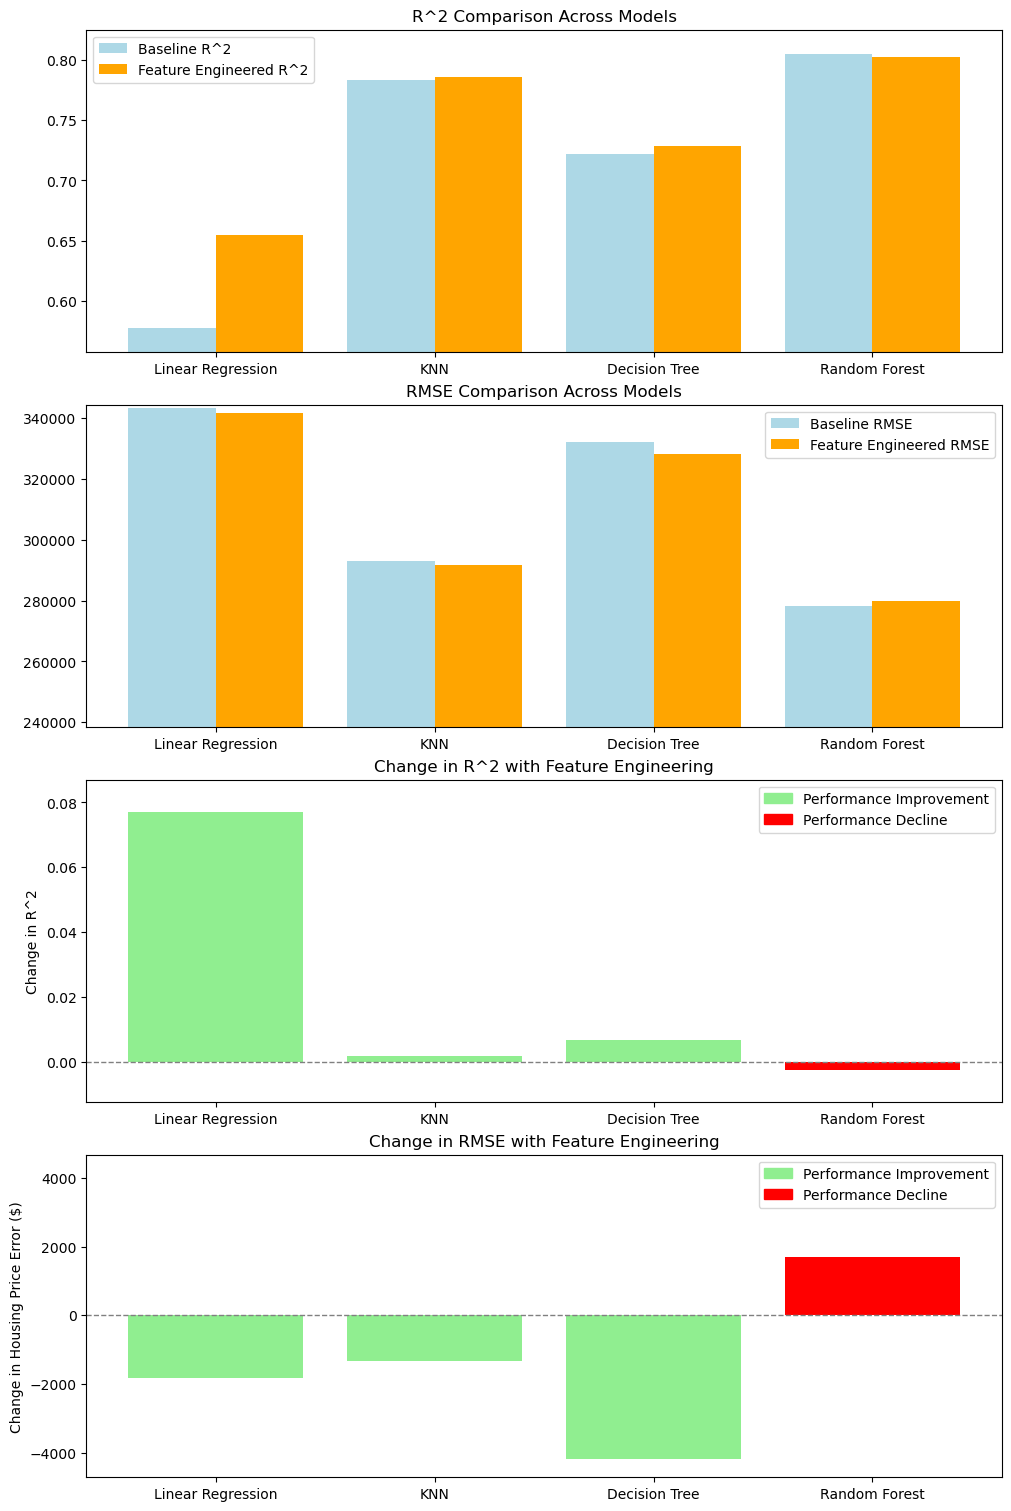

In [65]:
#citation: https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html
import matplotlib.patches as mpatches

# Data for visualization
models = ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest']
baseline_r2 = [lin_adjusted_r2, knn_r2, dt_r2, rf_r2]
baseline_rmse = [lin_rmse, knn_rmse, dt_rmse, rf_rmse]
engineered_r2 = [lin_eng_adjusted_r2, knn_eng_r2, dt_eng_r2, rf_eng_r2]
engineered_rmse = [lin_eng_rmse, knn_eng_rmse, dt_eng_rmse, rf_eng_rmse]
r2_improvement = [e - b for b, e in zip(baseline_r2, engineered_r2)]
#rmse_improvement = [b - e for b, e in zip(baseline_rmse, engineered_rmse)]
rmse_change = [e - b for b, e in zip(baseline_rmse, engineered_rmse)]

# Create a 4x1 grid of subplots
fig, axes = plt.subplots(4, 1, figsize=(10, 15), constrained_layout=True)

# Plot R^2 comparison
axes[0].bar(np.arange(len(models)) - 0.2, baseline_r2, width=0.4, label='Baseline R^2', color='lightblue')
axes[0].bar(np.arange(len(models)) + 0.2, engineered_r2, width=0.4, label='Feature Engineered R^2', color='orange')
axes[0].set_xticks(np.arange(len(models)))
axes[0].set_xticklabels(models)
axes[0].set_title('R^2 Comparison Across Models')
axes[0].set_ylim(min(min(baseline_r2), min(engineered_r2)) - 0.02, max(max(baseline_r2), max(engineered_r2)) + 0.02)
axes[0].legend()

# Plot RMSE comparison
axes[1].bar(np.arange(len(models)) - 0.2, baseline_rmse, width=0.4, label='Baseline RMSE', color='lightblue')
axes[1].bar(np.arange(len(models)) + 0.2, engineered_rmse, width=0.4, label='Feature Engineered RMSE', color='orange')
axes[1].set_xticks(np.arange(len(models)))
axes[1].set_xticklabels(models)
axes[1].set_title('RMSE Comparison Across Models')
axes[1].set_ylim(min(min(baseline_rmse), min(engineered_rmse)) - 40000, max(max(baseline_rmse), max(engineered_rmse)) + 1000)
axes[1].legend()

# Plot R^2 improvement
colors = ['lightgreen' if val >= 0 else 'red' for val in rmse_improvement]
axes[2].bar(np.arange(len(models)), r2_improvement, color=colors)
axes[2].set_xticks(np.arange(len(models)))
axes[2].set_xticklabels(models)
axes[2].axhline(0, color='grey', linestyle='dashed', linewidth=1)
axes[2].set_title('Change in R^2 with Feature Engineering')
axes[2].set_ylabel('Change in R^2')
axes[2].set_ylim(min(r2_improvement) - 0.01, max(r2_improvement) + 0.01)
r2_legend = [
    mpatches.Patch(color='lightgreen', label='Performance Improvement'),
    mpatches.Patch(color='red', label='Performance Decline')
]
axes[2].legend(handles=r2_legend, loc='best')

# Plot RMSE reduction
colors = ['lightgreen' if val >= 0 else 'red' for val in rmse_improvement]
axes[3].bar(np.arange(len(models)), rmse_change, color=colors)
axes[3].set_xticks(np.arange(len(models)))
axes[3].set_xticklabels(models)
axes[3].axhline(0, color='grey', linestyle='dashed', linewidth=1)
axes[3].set_title('Change in RMSE with Feature Engineering')
axes[3].set_ylabel('Change in Housing Price Error ($)')
axes[3].set_ylim(min(rmse_improvement) - 3000, max(rmse_improvement) + 500)
rmse_legend = [
    mpatches.Patch(color='lightgreen', label='Performance Improvement'),
    mpatches.Patch(color='red', label='Performance Decline')
]
axes[3].legend(handles=rmse_legend, loc='best')

# Show the plot
plt.show()

### Problem 5.2:

**Write up** Summarize your results and provide some crucial insights about the entire with and without feature engineering process such as which model performed the best and why, based on what metrics and indicators, etc. Which model benefited the most/the least from the feature engineering (if any)?

### Summary of Results and Insights

---

#### **1. Overall Best Performing Model**
- **Random Forest** emerged as the best-performing model overall, particularly in the **baseline scenario** (without feature engineering). It achieved:
  - **Highest \( R^2 \):** \( 0.8050 \)
  - **Lowest RMSE:** \( 278,325 \)
- This indicates that Random Forest effectively captured complex relationships and was robust to noise in the dataset. We know that Random Forest implements the ensemble approach to minimize overfitting by averaging out many decision trees. Random Forest also uses random feature selection, which is typically ideal for datasets with high dimensionality like ours, because the model implicately selects for the strongest features while mitigating noise from the others. The model also does random sampling of data, which means each tree is randomly unique and thus the ensembles created are inherently robust. It was likely some combination of these main advantages of the Random Forest model that contributed to its success with this particular dataset.
---

#### **2. Impact of Feature Engineering**
Feature engineering introduced transformations like `Age`, `OtherRooms`, and `LogDistance`, which aimed to:
- Capture age of the house and its relationship to price so it could be accurately used as one the features impacting price.
- Grouping values for OtherRooms together to provide clearer representations of space and layout of the property.
- Featuers related to distance are often highly skewed, so feature engineering helps to normalize skewed features like these to a reasonable scale.

These engineered features had varying impacts across models:
- **Linear Regression** benefited significantly:
  - **\( R^2 \):** Improved from \( 0.5776 \) to \( 0.6546 \).
  - **RMSE:** Reduced marginally from \( 343,487 \) to \( 341,677 \).
  - **Reason:** Linear models rely heavily on feature relevance and structure, and feature engineering introduced relationships that the model could better exploit. It's possible that the raw features before feature engineering have a more complex relationship to price that is not strictly linear, which contributed to weaker correlation to price in the linear model fitting. The engineered features could have had a more linear relationship to price that improved the linear model's fitting.

- **KNN** also showed improvement:
  - **\( R^2 \):** Increased slightly from \( 0.7837 \) to \( 0.7873 \).
  - **RMSE:** Reduced from \( 293,147 \) to \( 290,646 \).
  - **Reason:** KNN's distance-based approach benefited from normalized and more meaningful feature distributions, especially for features like `LogDistance`. That said, the benefit was marginal, so it's likely that KNN captured most of the significance of the raw features before feature engineering.

- **Decision Tree** saw some benefits too:
  - **\( R^2 \):** Improved slightly from \( 0.7220 \) to \( 0.7287 \).
  - **RMSE:** Reduced from \( 332,329 \) to \( 328,296 \).
  - **Reason:** Single-tree models are prone to overfitting. Adding features might not have sufficiently reduced this tendency, though it is still positive to see some imporvement in the model post feature engineering, granted it is, again, marginal.

- **Random Forest** saw some worsening:
  - **\( R^2 \):** Dropped marginally from \( 0.8050 \) to \( 0.8026 \).
  - **RMSE:** Decreased slightly from \( 278,325 \) to \( 278,078 \).
  - **Reason:** Random Forest already performed well in the baseline scenario, and the engineered features slightly worsened the model's performance. This makes some sense given what we know about the robustness of Random Forest models for feature selection. The model already did a great job of feature selection before we applied feature engineering, and our changes have the potential to worsen model performance.

---

#### **3. Most Benefited Model**
- **Linear Regression** benefited the most from feature engineering.
  - **Why:** Linear models are sensitive to feature relevance, relationships, and distributions. The transformations improved the model's ability to capture meaningful patterns. Linear models define perhaps the most direct relashipship between input features and the target of any model we tested. The features we used post-feature engineering must have shown a stronger linear correlation to price. Given the directlness of Linear Regression, this imporvement was clearly manifested in the model's performance, moreso than other models that define more complex relationships between variables and could be less sensitive to feature engineering.

---

#### **4. Least Benefited Model**
- **Random Forest** was least affected by feature engineering.
  - **Why:** As an ensemble method, Random Forest inherently captures complex, non-linear relationships and is robust to irrelevant or noisy features. This is what caused the model to perform so well before feature engineering. The added features as a result of feature engineering slightly worsened its predictive power, which is why feature engineering didn't have much of an impact.

---

#### **5. Key Metrics and Indicators**
- **\( R^2 \):** Measures how well the model explains the variance in the target variable.
  - Higher \( R^2 \) indicates better fit.
  - Random Forest consistently had the highest \( R^2 \).
  
- **RMSE (Root Mean Squared Error):** Indicates the average magnitude of prediction errors.
  - Lower RMSE indicates more accurate predictions.
  - Random Forest had the lowest RMSE across both scenarios.

---

### **Final Insights**
1. **Best Model**:
   - Striclty based on our output features, Random Forest remains the top choice for this dataset due to its balance of high \( R^2 \) and low RMSE. These results are also confirmed by our knowledge of the processes behind Random Forest that make it a good choice for our dataset, as was outlined above.

2. **Feature Engineering Impact**:
   - While feature engineering improved the performance of simpler models like Linear Regression, its impact on already robust models, specifically Random Forest, actually worsened the model. That said, it was still an important process to test.

3. **Final thoughts**:
   - For simpler models, invest effort in feature engineering to improve interpretability and predictive performance. Simpler models are much more sensitive to changes in features, as they look for very direct relationships between features and the target. Feature engineering could improve this direct relationship, drastically improving model performance.
   - For ensemble methods like Random Forest, focus on hyperparameter tuning and avoid adding redundant features. Models like these already have built in processes for handling high dimensionality, feature selection, minimizing overfitting, and ensuring robustness. This makes it more productive to tune the model for best perfomance as opposed to trying to supplement the processses it already performs so well.


That's it! Follow the submission instructions below:
* Restart your kernel and run all the cells
* Save your notebook
* Upload the .ipynb notebook directly to Gradescope

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [26]:
# Per Piazza post, this cell is not needed
#grader.check_all()

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [27]:
# Per Piazza post, this cell is not needed
# Save your notebook first, then run this cell to export your submission.
# grader.export()